# Hicks-Ray CSTR: the infinite horizon vs a long finite horizon

The model is the canonical declared Hicks-Ray CSTR from
[`models/hicks.py`](models/hicks.py): see the module for its construction.
Two cases of the same model. Case 1 runs five sampling steps with the
infinite-horizon terminal segment (`drto.infinite_horizon`,
[Dinh et al. 2025](https://doi.org/10.1016/j.jprocont.2025.103565)) carrying
the tail, which deactivates the declared terminal cost since the tail owns
the cost-to-go. Case 2 runs fifty steps of plain finite horizon with the
terminal cost live.

## Case 1: five samples plus the infinite-horizon tail

In [1]:
import pyomo.environ as pyo
import drto
from models.hicks import hicks
from drto import plot_states, plot_controls, plot_stage_cost

m1 = hicks(N=5)
pyo.TransformationFactory("dae.collocation").apply_to(m1, wrt=m1.t, nfe=5, ncp=3, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("drto.infinite_horizon").apply_to(
    m1,
    nfe=3,                    # finite elements on the terminal segment
    ncp=5,                    # Gauss-Legendre points per element
    beta=1.2,                 # tail overestimation factor, > 1
    gamma="rule",             # the mesh rule, tanh(gamma*h) = tau_11; pass a number to override
    profile="collocation",    # segment control profile (pyomo-cvp)
)
pyo.TransformationFactory("drto.parameterize").apply_to(m1)  # the finite-horizon profiles
drto.build_objective(m1)
pyo.SolverFactory("pounce").solve(m1, tee=True)

pounce: wrote C:\Users\Devin\AppData\Local\Temp\tmp093dyd42.pyomo.sol


********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.9.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmp093dyd42.pyomo.nl...
Parsed 181 vars, 

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 147, 'Number of variables': 181, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'POUNCE 0.9.0\\x3a SolveSucceeded', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 0.8403728008270264}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

In [2]:
drto.info(m1)

<drto registry>
states: 2, controls: 2
declarations:
  horizon: t (ContinuousSet, 16 points)
  states: zc (free), zt (free)
  dynamics: dzc[t]  ==  (1 - zc[t])/(u2sf*v2[t]) - k0*zc[t]*exp(- ea/zt[t])  for t in t
  dynamics: dzt[t]  ==  (ztf - zt[t])/(u2sf*v2[t]) + k0*zc[t]*exp(- ea/zt[t]) - a0*u1sf*v1[t]*(zt[t] - ztcw)  for t in t
  controls: v1 (piecewise_constant, free), v2 (piecewise_constant, free)
  tracking stage cost: cost[t]  ==  10*(zc[t] - zc_ss)**2 + 2*(zt[t] - zt_ss)**2 + (v1[t] - v1_ss)**2 + 0.5*(v2[t] - v2_ss)**2  for t in sorted(t)[:-1]
  terminal cost: term  ==  10*(zc[5] - zc_ss)**2 + 2*(zt[5] - zt_ss)**2
  initial conditions: zc[0]  ==  zc_hat
  initial conditions: zt[0]  ==  zt_hat
  steady-state targets: zc_ss (of zc), zt_ss (of zt)
  steady-state control targets: v1_ss (of v1), v2_ss (of v2)
  cost_group: drto_ih, drto_ih
transformations:
  drto.infinite_horizon: segment=3 elements x 5 Legendre points, beta=1.2, gamma=0.01563827, profile=collocation, horizon=kept, infinite tail appended, terminal_cost=terminal deactivated (the tail owns it), terminal=soft pin z(tau=1)=z_s on 2 states, mu=1000.0
  drto.parameterize: profiles=v1 (piecewise_constant), v2 (piecewise_constant)
  drto.build_objective: objective=sum of 28 weighted cost terms

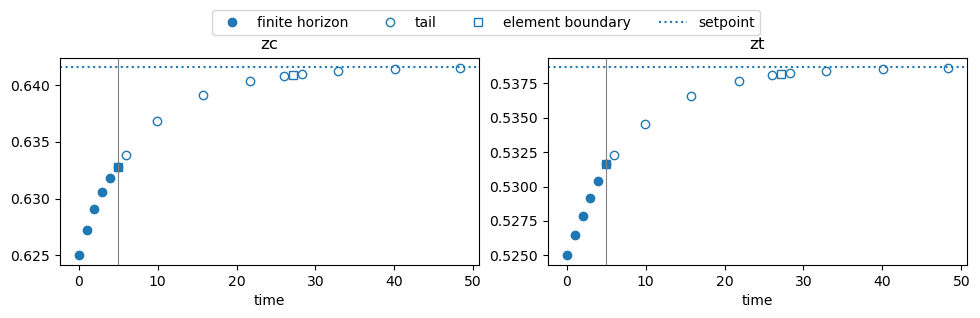

In [3]:
plot_states(m1);

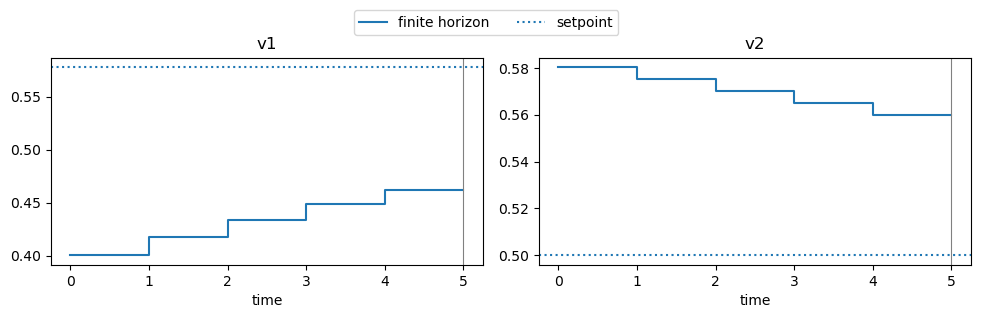

In [4]:
plot_controls(m1);

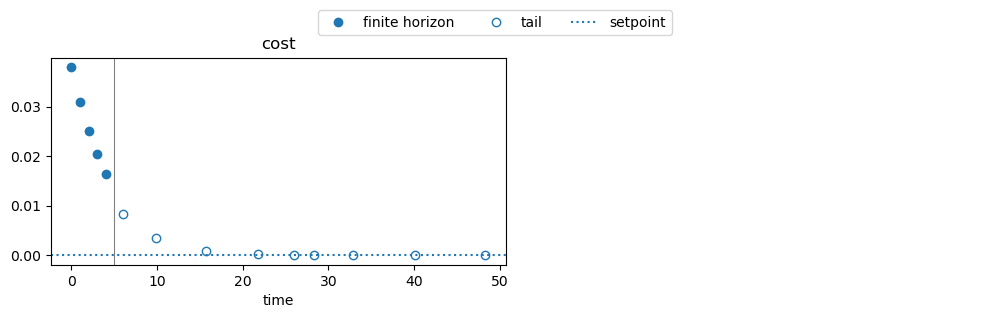

In [5]:
plot_stage_cost(m1);

## Case 2: fifty samples, finite horizon with the terminal cost

In [6]:
m2 = hicks(N=50)
pyo.TransformationFactory("dae.collocation").apply_to(m2, wrt=m2.t, nfe=50, ncp=3, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("drto.parameterize").apply_to(m2)
drto.build_objective(m2)
pyo.SolverFactory("pounce").solve(m2, tee=True)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.9.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmpqxsbs3mj.pyomo.nl...
Parsed 755 vars, 

   2  1.8645132e-01 2.10e-04 1.62e-02   -1.7 4.29e-03      - 1.00e+00 1.00e+00h  1
   3  1.6720380e-01 9.62e-04 5.15e-03   -3.8 1.38e-02      - 9.74e-01 1.00e+00h  1
   4  1.7668155e-01 2.99e-06 1.54e-05   -3.8 1.95e-03      - 1.00e+00 1.00e+00h  1
   5  1.7672213e-01 7.38e-08 2.08e-07   -5.7 1.20e-04      - 1.00e+00 1.00e+00h  1
   6  1.7672290e-01 1.19e-11 3.34e-11   -8.6 1.68e-06      - 1.00e+00 1.00e+00h  1


Number of Iterations....: 6

                                   (scaled)                 (unscaled)
Objective...............:   1.7672290497245915e-01    1.7672290497245915e-01
Dual infeasibility......:   3.3405039422552268e-11    3.3405039422552268e-11
Constraint violation....:   1.1897288563648072e-11    1.1897288563648072e-11
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   2.5115733361679281e-09    2.5115733361679281e-09
Overall NLP error.......:   2.5115733361679281e-09    2.5115733361679281e-09


Number of objective

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 655, 'Number of variables': 755, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'POUNCE 0.9.0\\x3a SolveSucceeded', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 0.7384097576141357}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

In [7]:
drto.info(m2)

<drto registry>
states: 2, controls: 2
declarations:
  horizon: t (ContinuousSet, 151 points)
  states: zc (free), zt (free)
  dynamics: dzc[t]  ==  (1 - zc[t])/(u2sf*v2[t]) - k0*zc[t]*exp(- ea/zt[t])  for t in t
  dynamics: dzt[t]  ==  (ztf - zt[t])/(u2sf*v2[t]) + k0*zc[t]*exp(- ea/zt[t]) - a0*u1sf*v1[t]*(zt[t] - ztcw)  for t in t
  controls: v1 (piecewise_constant, free), v2 (piecewise_constant, free)
  tracking stage cost: cost[t]  ==  10*(zc[t] - zc_ss)**2 + 2*(zt[t] - zt_ss)**2 + (v1[t] - v1_ss)**2 + 0.5*(v2[t] - v2_ss)**2  for t in sorted(t)[:-1]
  terminal cost: term  ==  10*(zc[50] - zc_ss)**2 + 2*(zt[50] - zt_ss)**2
  initial conditions: zc[0]  ==  zc_hat
  initial conditions: zt[0]  ==  zt_hat
  steady-state targets: zc_ss (of zc), zt_ss (of zt)
  steady-state control targets: v1_ss (of v1), v2_ss (of v2)
transformations:
  drto.parameterize: profiles=v1 (piecewise_constant), v2 (piecewise_constant)
  drto.build_objective: objective=sum of 51 weighted cost terms

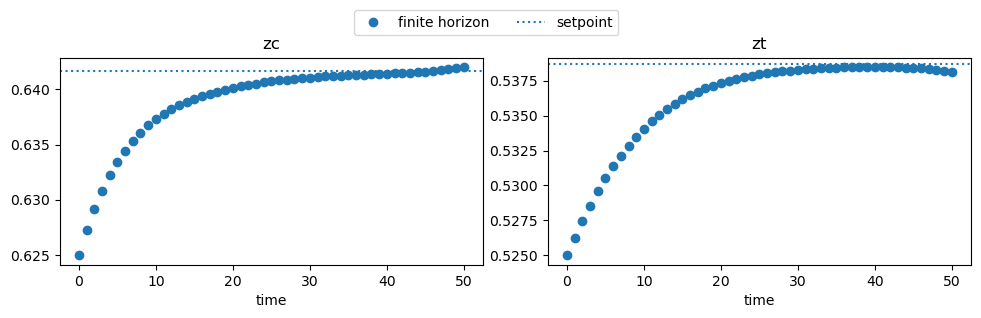

In [8]:
plot_states(m2);

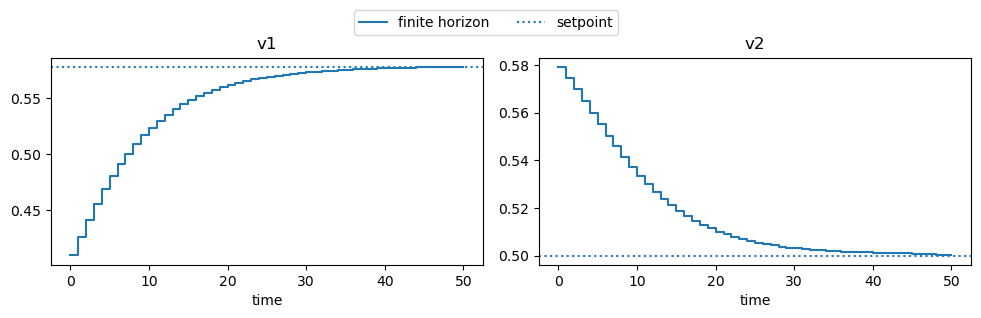

In [9]:
plot_controls(m2);

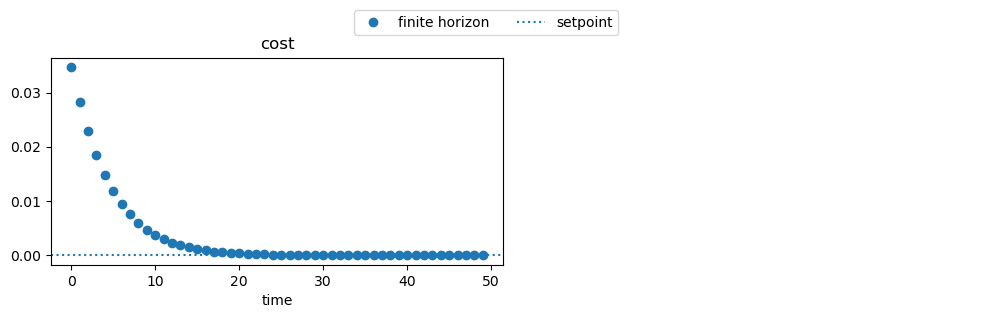

In [10]:
plot_stage_cost(m2);